In [137]:
def overlap_coefficient(str1, str2):
    """计算两个字符串的重合系数"""
    words_str1 = set(str1.split())
    words_str2 = set(str2.split())
    intersection = words_str1 & words_str2
    return len(intersection) / max(len(words_str1), len(words_str2))

def edit_distance(str1, str2):
    """计算两个字符串之间的编辑距离，考虑重合度，并除以最长字符串的长度"""
    len_str1 = len(str1)
    len_str2 = len(str2)
    
    # 保证 len_str1 <= len_str2，优化空间复杂度
    if len_str1 > len_str2:
        str1, str2 = str2, str1
        len_str1, len_str2 = len_str2, len_str1
    
    # 创建一个长度为 len_str1 + 1 的数组
    previous_row = list(range(len_str1 + 1))
    current_row = [0] * (len_str1 + 1)

    for j in range(1, len_str2 + 1):
        current_row[0] = j
        for i in range(1, len_str1 + 1):
            if str1[i - 1] == str2[j - 1]:
                current_row[i] = previous_row[i - 1]
            else:
                current_row[i] = 1 + min(previous_row[i],      # 删除
                                         current_row[i - 1],   # 插入
                                         previous_row[i - 1])  # 替换
        previous_row, current_row = current_row, previous_row

    # 计算重合度
    coeff = overlap_coefficient(str1, str2)
    # 考虑重合度的编辑距离
    adjusted_distance = previous_row[len_str1] * (1 - coeff)
    # 标准化编辑距离
    normalized_distance = adjusted_distance / max(len_str1, len_str2)
    
    return normalized_distance

# 测试代码
words = ['water', 'di water', 'air', 'gas', 'oxygen', 'cmc', 'd10', 'dbd', 'oil', 'pure water']
for word in words:
    print(f"Normalized distance between 'water' and '{word}': {edit_distance('water', word)}")


Normalized distance between 'water' and 'water': 0.0
Normalized distance between 'water' and 'di water': 0.1875
Normalized distance between 'water' and 'air': 0.6
Normalized distance between 'water' and 'gas': 0.8
Normalized distance between 'water' and 'oxygen': 0.8333333333333334
Normalized distance between 'water' and 'cmc': 1.0
Normalized distance between 'water' and 'd10': 1.0
Normalized distance between 'water' and 'dbd': 1.0
Normalized distance between 'water' and 'oil': 1.0
Normalized distance between 'water' and 'pure water': 0.25


In [138]:
#用来寻找到各个字符串距离最短的函数

def find_closest_string(str_list):
    """ 找到列表中与其他所有字符串编辑距离最小的字符串 """
    min_distance = float('inf')
    closest_string = ""

    for str1 in str_list:
        total_distance = sum(edit_distance(str1, str2) for str2 in str_list)
        if total_distance < min_distance:
            min_distance = total_distance
            closest_string = str1

    return closest_string

# 示例
strings = ["apple", "apricot", "banana", "berry", "cherry"]
print(find_closest_string(strings))
print(edit_distance("1:5000 (by mass) solution of surfactant (tween 80, merck)-deionized water", "WATER"))
print(edit_distance("water", "WATER"))

berry
1.0
1.0


estimated_value(arithmetic_sequence(weight_0_for_density_init),"water","density")


'water', 'di water', 'air', 'gas', 'oxygen', 'cmc', 'd10', 'dbd', 'oil', 'pure water', 'co2', 'n2', 'scmc', 'il', 'ethanol', 'glycerol', 'liquid', 'octanol', 'aqueous', 'white oil', 'alginate', 'n-octane', 'fluid 2', 'fluid 1', 'castor oil', 'methanol'


原来的编辑距离方法有点问题，单词越短编辑距离越小。但是我想让那些包含“water”的词组离water的距离更近，哪怕他们会更长


In [139]:
import math

# 假定这是给定的列表
lst = [1, 'NAN', 2, 'N/A', 3, float('nan'), 4, None, 5]

# 删除所有 nan 值以及类似 'NAN'、'N/A' 的字符串
cleaned_lst = [x for x in lst if x is not None and x != 'N/A ' and x != 'N/A' and not (isinstance(x, float) and math.isnan(x))]

# 输出结果
print(cleaned_lst)


#空值会影响算法，所以要删掉
def drop_nan(lst):
    #print(lst)
    cleaned_lst = [x for x in lst if x is not None and x != '/ 'and x != '' and x != 'N' and 'N/A' not in str(x) and not (isinstance(x, float) and math.isnan(x))]
    #print(cleaned_lst)
    return cleaned_lst

[1, 'NAN', 2, 3, 4, 5]


In [140]:
#用来压缩列表的函数
from statistics import median, multimode

def analyze_list(lst):
    #先清除空值
    lst = drop_nan(lst)
    # 检查列表是否有重复的元素
    modes = multimode(lst)
    if len(lst) != len(set(lst)): #如果有元素出现了不止一次
        # 如果有重复元素，返回众数
        return modes[0]
    else:
        # 尝试将列表中的元素转换为数字
        try:
            numeric_list = [float(x) for x in lst]
            # 返回中位数
            return median(numeric_list)
        except ValueError:
            # 如果转换失败，返回 find_closest_string(strings
            str_list = [str(item) for item in lst]
            return find_closest_string(str_list)

# 测试函数
test_lists = [
    [1, 2, 3, 4, 5],
    ["apple", "apricot", "banana", "berry", "cherry"],
    [1, 2, "a", 3,"apple"],
    [1, 2, 3, 3, 4, 5],
    [1.5, 2.5, 3.5, 4.5]
]

results = [analyze_list(lst) for lst in test_lists]
results


[3.0, 'berry', 'a', 3, 3.0]

In [141]:
import re
#把所有正负号以及后面的尾巴去掉
def remove_pm(content):
    # 使用正则表达式匹配“±”及其后的内容，直到逗号或"]"
    pattern = r'±[^,\]]*'
    
    # 找到所有匹配项
    matches = re.findall(pattern, content)
    
    # 对于每个匹配项，检查其后的字符
    for match in matches:
        # 如果“±”后面是逗号或"]"，则保留这些字符
        if match[-1] in [',', ']']:
            content = content.replace(match, '', 1)
        else:
            # 如果“±”后面不是逗号或"]"，则删除“±”及其后的所有内容
            pm_pattern = re.escape(match)
            content = re.sub(pm_pattern, '', content, count=1)
    
    return content

# 测试代码
test_str = "这是一个测试字符串±sss, 另一个测试字符串, 以及一个±ssss]特殊的字符串, 最后一个±测试字符串"
print(remove_pm(test_str))

这是一个测试字符串, 另一个测试字符串, 以及一个]特殊的字符串, 最后一个


In [142]:
#用来标准化字符串的函数

def process_string_with_dict(s, replacement_dict):
    
    if isinstance(s, str):
        #把所有正负号以及后面的尾巴去掉
        s = remove_pm(s)

        for pattern, replacement in replacement_dict.items():
            s = s.replace(pattern, replacement)

        #print(s)

        try:
            num = float(s)
            return num
        except:
            return s
    
    else:
        return s

# Define the replacement rules in a dictionary
replacement_rules = {
    " ": "",       # Remove all spaces
    "×10": "e",    # Replace "×10" with "e"
    "−": "-" ,      # Replace "−" with "-"
    "^":""
}

# Example usage
example_string = "3.14 ± 0.01 ×10^2, ]− 2.71"
processed_string = process_string_with_dict(example_string, replacement_rules)
processed_string


'3.14,]-2.71'

In [143]:
import pandas as pd

# 主函数，将输入的DataFrame转换为1行m列的DataFrame
def transform_df(input_df):
    # 初始化一个空的DataFrame
    output_df = pd.DataFrame()
    
    # 对输入DataFrame的每一列执行操作
    for column in input_df.columns:
        # 转换为列表并执行analyze_list(lst)
        result = analyze_list(input_df[column].tolist())
        # 将结果赋值给新DataFrame的对应列
        '''
        if column == 'd_viscosity':
            print(input_df[column].tolist())
            print(result)
        '''
            
        output_df[column] = [result]
    
    return output_df

# 示例使用
# 创建一个示例的DataFrame
example_df = pd.DataFrame({
    'A': [1, 2, 3, 4],
    'B': [5, 6, 7, 8],
    'C': [9, 10, 11, 12]
})

# 调用函数
transformed_df = transform_df(example_df)
print(transformed_df)


     A    B     C
0  2.5  6.5  10.5


In [144]:
#用来展平的函数
def flatten_list(multi_list):
    flat_list = []
    for item in multi_list:
        if isinstance(item, list):
            # 如果元素是列表，则递归调用flatten_list
            flat_list.extend(flatten_list(item))
        else:
            # 如果元素不是列表，则直接添加到flat_list中
            flat_list.append(item)
    return flat_list

# 示例使用
multi_list = [1, [2, [3, 4], 5], 6, [7], 8]
result = flatten_list(multi_list)
print(result)  # 输出: [1, 2, 3, 4, 5, 6, 7, 8]


[1, 2, 3, 4, 5, 6, 7, 8]


In [145]:
import pandas as pd
import ast

# 这是将每个单元格的列表传给 analyze_list 函数的函数
def process_df(df):
    #print(df)
    for column in df.columns:
        for index in df.index:
            
            
            #为防止多层列表，可以直接展平
                
            cell_value = df.at[index, column]
            
            #print(f'转换前{df.at[index, column]}')
            if "_content" not in column: #对组成不处理
                cell_value = process_string_with_dict(cell_value, replacement_rules) #process_string_with_dict会自动识别字符串

            # 尝试将单元格内容转换为列表
            try:
                if "_content" not in column: #对组成不处理
                    cell_value = cell_value.replace(" ", "")
                cell_value = ast.literal_eval(cell_value) #转换成列表
                cell_value_flatted = flatten_list(cell_value)
                #对每个对象执行字符串处理
                if "_content" not in column: #对组成不处理
                    cell_value_flatted = [process_string_with_dict(item, replacement_rules) for item in cell_value_flatted]
                
                df.at[index, column] = analyze_list(cell_value_flatted)
            except Exception as e:
                # 如果转换失败，说明是单独对象，直接保留原来的值就行

                #cell_value = process_string_with_dict(cell_value, replacement_rules)
                df.at[index, column] = cell_value
                try:
                    if '0.07122' in cell_value:
                        print(e)
                        print(cell_value,'\n\n\n')
                except:
                    pass
                
                pass
            #print(f'转换后{df.at[index, column]}')
                        
            #处理空值
            if df.at[index, column] == '/' or df.at[index, column] == '[]':
                df.at[index, column] = None
            #if isinstance(df.at[index, column], list):
                #print(df.at[index, column])
    #print(df)
    return df

# 示例 DataFrame
data = {
    'A': [[1, 2, 3], [4, 5], [6, 7, 8, 9]],
    'B': [10, "ssad1", 12],
    'C': [13, [14, 15], [16, 17]]
}
df = pd.DataFrame(data)


In [146]:
import pandas as pd

def process_csv_2_row(file_name):
    # 读取CSV文件
    df = pd.read_csv(file_name)
    
    # 对DataFrame进行处理
    df_new = process_df(df)
    #print(df_new["type"])
    transformed_df = transform_df(df_new)
    #print(transformed_df["type"])
    return transformed_df


In [147]:
import os
import pandas as pd

# 初始化一个空的DataFrame，用于存储合并后的结果
merged_df = pd.DataFrame()

# 指定要遍历的文件夹
folder_path = 'summarized_result_change_unit'

# 遍历文件夹中的所有文件
for file_name in os.listdir(folder_path):
    # 检查文件是否为CSV文件
    if file_name.endswith('.csv'):
        # 构建完整的文件路径
        file_path = os.path.join(folder_path, file_name)
        # 调用 process_csv_2_row 函数处理文件，并获取返回的DataFrame
        processed_df = process_csv_2_row(file_path)
        # 将处理后的DataFrame合并到merged_df中
        merged_df = pd.concat([merged_df, processed_df], ignore_index=True)

# 将最终的merged_df保存为CSV文件
output_file = 'post//merged_results.csv'
merged_df.to_csv(output_file, index=False,encoding = 'utf-8')


In [148]:
merged_df

,Unnamed: 0,type,c_content,c_Q,c_V,c_density,c_viscosity,c_interface tension,c_channel’s width,c_channel’s depth,...,d_content,d_Q,d_V,d_density,d_viscosity,d_interface tension,d_channel’s width,d_channel’s depth,d_weber number,d_capillary number
0,11.5,squeezing,Silicone oil KF96-10cs,0.0,,,0.000034,0.000010–0.000050,0.2,0.1,...,water,,,,,,,,,
1,10.5,jetting,50 wt% glycerol solution with 1 wt% SDS,0.000037,,,0.00692,0.018125,0.108,0.75,...,gas,0.000002,,,0.000194,,,,,
2,15.5,jetting,Isobutylene-isoprene rubber (IIR) solution,0.000023,,696.0,0.1422,0.02953,0.4,0.365,...,Deionized water,0.000001,,998.0,0.00089,0.001,0.075,,0.0457,
3,14.0,squeezing,oil,,0.18,,,,,,...,water,,0.18,,,,0.2,0.1,,
4,15.5,squeezing,Kerosene,,0.2,,,,,6.0,...,Water,,,,,,,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336,10.5,dripping,mineral oil with a surfactant (Span 80) at a c...,0.0,,,,,0.1,0.05,...,DI water with 60.5 wt. % glycerin,0.0,,,0.009,0.00334,0.1,,,
337,3.0,dripping,oil,,0.4322,1940.0,0.00233,0.0211,,,...,crystallization solution,0.0,,1013.0,0.00028,,0.508,,,
338,19.5,squeezing,ethanol,0.0,,809.0,0.001005,0.0259,0.2,0.152,...,ethanol (liquid),0.000003,,179.0,0.00002,,0.2175,0.866,,
339,7.0,squeezing,Liquid,,,,0.1,0.0208,,,...,Silicone oil 47V100,2.52,,,1.1,0.0629,,,,




ok现在拿到df了，下一步是处理数据





密度过大的缩放到1000规模



密度和黏度：

1.建立一个简单的标准数据库，名字在册的对黏度和密度进行补齐

如果已经有了，但是和标准的差的太多，使用标准的

2.根据里面信息建立一个互助数据库，名字在册的也可以进行补齐

3.根据编辑距离进行补齐



删掉没有液滴类型的

流速过快的drop掉流速；流速不完备的drop掉整行（取平均值也没用，范围变化有点大）

In [149]:
#先都转换为数字形式


# 定义一个函数来尝试转换单元格为数字
def try_convert_to_number(cell):
    try:
        return pd.to_numeric(cell)
    except ValueError:
        return cell

# 计数无法转换的且不是空白的单元格
def count_non_numeric_cells(df):
    non_numeric_counts = {}
    total_counts = df.shape[0]
    for column in df.columns:
        non_numeric_count = df[column].apply(lambda x: isinstance(try_convert_to_number(x), str) and x.strip() != '').sum()
        percentage = (non_numeric_count / total_counts) * 100
        non_numeric_counts[column] = f'{percentage:.2f}%'
    return non_numeric_counts

# 对每个单元格尝试转换为数字
converted_df = merged_df.applymap(try_convert_to_number)

# 统计每列无法转换的且不是空白的单元格数和百分比
non_numeric_stats = count_non_numeric_cells(merged_df)

# 输出结果
#print("转换后的DataFrame：")
#print(converted_df)
print("\n每列无法转换的且不是空白的单元格数和百分比：")
print(non_numeric_stats)

merged_df = converted_df




每列无法转换的且不是空白的单元格数和百分比：
{'Unnamed: 0': '0.00%', 'type': '96.77%', 'c_content': '96.19%', 'c_Q': '0.00%', 'c_V': '0.00%', 'c_density': '0.59%', 'c_viscosity': '0.29%', 'c_interface tension': '2.05%', 'c_channel’s width': '1.17%', 'c_channel’s depth': '0.59%', 'c_weber number': '0.00%', 'c_capillary number': '0.00%', 'd_content': '97.07%', 'd_Q': '0.00%', 'd_V': '0.00%', 'd_density': '0.88%', 'd_viscosity': '0.00%', 'd_interface tension': '0.59%', 'd_channel’s width': '0.88%', 'd_channel’s depth': '0.00%', 'd_weber number': '0.00%', 'd_capillary number': '0.00%'}


C:\Users\Krog\AppData\Local\Temp\ipykernel_19152\2667029654.py:22: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  converted_df = merged_df.applymap(try_convert_to_number)


In [150]:
stats_df  = pd.DataFrame([non_numeric_stats])

# 将百分比转换为浮点数并计算1-值
for column in stats_df.columns:
    stats_df[column] = 1 - float(stats_df[column].str.rstrip('%')) / 100

stats_df

C:\Users\Krog\AppData\Local\Temp\ipykernel_19152\2490088003.py:5: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  stats_df[column] = 1 - float(stats_df[column].str.rstrip('%')) / 100


,Unnamed: 0,type,c_content,c_Q,c_V,c_density,c_viscosity,c_interface tension,c_channel’s width,c_channel’s depth,...,d_content,d_Q,d_V,d_density,d_viscosity,d_interface tension,d_channel’s width,d_channel’s depth,d_weber number,d_capillary number
0,1.0,0.0323,0.0381,1.0,1.0,0.9941,0.9971,0.9795,0.9883,0.9941,...,0.0293,1.0,1.0,0.9912,1.0,0.9941,0.9912,1.0,1.0,1.0


In [151]:
merged_df

,Unnamed: 0,type,c_content,c_Q,c_V,c_density,c_viscosity,c_interface tension,c_channel’s width,c_channel’s depth,...,d_content,d_Q,d_V,d_density,d_viscosity,d_interface tension,d_channel’s width,d_channel’s depth,d_weber number,d_capillary number
0,11.5,squeezing,Silicone oil KF96-10cs,7.800000e-09,NaN,NaN,0.000034,0.000010–0.000050,0.2,0.1,...,water,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10.5,jetting,50 wt% glycerol solution with 1 wt% SDS,3.666667e-05,NaN,NaN,0.00692,0.018125,0.108,0.75,...,gas,1.666667e-06,NaN,NaN,0.000194,NaN,NaN,NaN,NaN,NaN
2,15.5,jetting,Isobutylene-isoprene rubber (IIR) solution,2.270833e-05,NaN,696.0,0.1422,0.02953,0.4,0.365,...,Deionized water,5.205000e-07,NaN,998.0,0.000890,0.001,0.075,NaN,0.0457,NaN
3,14.0,squeezing,oil,NaN,0.1800,NaN,NaN,NaN,NaN,NaN,...,water,NaN,0.18,NaN,NaN,NaN,0.2,0.100,NaN,NaN
4,15.5,squeezing,Kerosene,NaN,0.2000,NaN,NaN,NaN,NaN,6.0,...,Water,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336,10.5,dripping,mineral oil with a surfactant (Span 80) at a c...,1.666667e-07,NaN,NaN,NaN,NaN,0.1,0.05,...,DI water with 60.5 wt. % glycerin,1.666667e-09,NaN,NaN,0.009000,0.00334,0.1,NaN,NaN,NaN
337,3.0,dripping,oil,NaN,0.4322,1940.0,0.00233,0.0211,NaN,NaN,...,crystallization solution,2.910000e-07,NaN,1013.0,0.000280,NaN,0.508,NaN,NaN,NaN
338,19.5,squeezing,ethanol,5.000000e-08,NaN,809.0,0.001005,0.0259,0.2,0.152,...,ethanol (liquid),3.000000e-06,NaN,179.0,0.000020,NaN,0.2175,0.866,NaN,NaN
339,7.0,squeezing,Liquid,NaN,NaN,NaN,0.1,0.0208,NaN,NaN,...,Silicone oil 47V100,2.520000e+00,NaN,NaN,1.100000,0.0629,NaN,NaN,NaN,NaN


In [152]:
# 对包含"_density"的列进行操作将过大的处理掉
for col in merged_df.columns:
    if '_density' in col:
        for index in merged_df.index:
            try:
                while merged_df.at[index, col] > 10000:
                    merged_df.at[index, col] /= 1000

            
            except:
                print([index, col])
                print(merged_df.at[index, col])
                
            #if merged_df.at[index, col] < 500:
                #print([index, col],merged_df.at[index, col],merged_df.at[index, col[0:2]+"content"],'\n\n')

#print(merged_df)

[164, 'c_density']
['1037,'1052,'1067,'1052,'1052,'1053,'1053,'1054,'1055]
[211, 'c_density']
['1004,'1015,'1032,'1063]
[124, 'd_density']
['1050]
[175, 'd_density']
#Here,celldensitydoesnothaveadirectconversiontokg/m³withoutadditionaldata.
[334, 'd_density']
825–850


In [153]:
merged_df.columns[13:]

Index(['d_Q', 'd_V', 'd_density', 'd_viscosity', 'd_interface tension',
       'd_channel’s width', 'd_channel’s depth', 'd_weber number',
       'd_capillary number'],
      dtype='object')

In [154]:
#迭代循环找需要手动操作的
import pandas as pd

def print_string_objects(df, prop):
    """
    遍历DataFrame中指定列，如果对象是字符串则打印。

    参数:
    df -- pandas DataFrame对象
    prop -- 字符串，指定要遍历的列名
    """
    # 遍历指定列的每个元素
    for index, row in df.iterrows():
        # 获取指定列的值
        item = row[prop]
        try:
            # 尝试将对象转换为数字
            numeric_value = pd.to_numeric(item, errors='raise')
            if numeric_value==0 :
                print(f"行索引: {index}, 列名: {prop}, 值: {item}")
        except ValueError:
            # 如果转换失败，打印行列信息
            print(f"行索引: {index}, 列名: {prop}, 值: {item}")

# 示例使用该函数
# 假设有一个DataFrame 'df' 和一个列名 'column_name'
# df = pd.DataFrame({'column_name': ['hello', 123, 'world', True]})
# print_string_objects(df, 'column_name')
for col_name in merged_df.columns[3:12]:
    print_string_objects(merged_df, col_name)
for col_name in merged_df.columns[13:]:
    print_string_objects(merged_df, col_name)

行索引: 164, 列名: c_density, 值: ['1037,'1052,'1067,'1052,'1052,'1053,'1053,'1054,'1055]
行索引: 211, 列名: c_density, 值: ['1004,'1015,'1032,'1063]
行索引: 121, 列名: c_viscosity, 值: 0.0001and0.8
行索引: 0, 列名: c_interface tension, 值: 0.000010–0.000050
行索引: 19, 列名: c_interface tension, 值: '0.0015
行索引: 27, 列名: c_interface tension, 值: 0.01388–0.01624
行索引: 99, 列名: c_interface tension, 值: 0.0
行索引: 183, 列名: c_interface tension, 值: 0.0
行索引: 211, 列名: c_interface tension, 值: ['0.028,'0.028,'0.020,'0.020]
行索引: 250, 列名: c_interface tension, 值: [0.005,0.005,0.003to0.012]
行索引: 266, 列名: c_interface tension, 值: 0.0365-0.1095
行索引: 321, 列名: c_interface tension, 值: 0.03298–0.03511
行索引: 172, 列名: c_channel’s width, 值: 0.0624-0.0708
行索引: 238, 列名: c_channel’s width, 值: 0.03–0.05
行索引: 255, 列名: c_channel’s width, 值: [0.01-0.1,1]
行索引: 309, 列名: c_channel’s width, 值: 0.25–3
行索引: 200, 列名: c_channel’s depth, 值: 0.0
行索引: 212, 列名: c_channel’s depth, 值: 0.004–0.011
行索引: 334, 列名: c_channel’s depth, 值: 0.1–0.12
行索引: 24, 列名: c_capillary

In [155]:
#手动操作统一汇集在这里

#处理乱码的表面张力
def modify_and_print(df, row_index, column_name, number):
    # 打印原始内容
    original_value = df.at[row_index, column_name]
    print(f"原始内容位于({row_index}, '{column_name}')：{original_value}")

    # 修改内容为指定数字
    df.at[row_index, column_name] = number
    print(f"修改后的内容位于({row_index}, '{column_name}')：{number}")
    
# c_density
modify_and_print(merged_df, 164, "c_density", 1052)  # 众数为1052
modify_and_print(merged_df, 211, "c_density", 1023.5)  # 中位数为1023.5

# c_viscosity
modify_and_print(merged_df, 121, "c_viscosity", 0.4)  # 中位数为0.4

# c_interface tension
modify_and_print(merged_df, 0, "c_interface tension", 0.00003)  # 中位数为0.00003
modify_and_print(merged_df, 19, "c_interface tension", 0.0015)
modify_and_print(merged_df, 27, "c_interface tension", 0.01506)  # 中位数为0.01506
modify_and_print(merged_df, 99, "c_interface tension", pd.NA)
modify_and_print(merged_df, 183, "c_interface tension", pd.NA)
modify_and_print(merged_df, 211, "c_interface tension", 0.024)  # 众数为0.028和0.020，故中位数为0.024
modify_and_print(merged_df, 250, "c_interface tension", 0.005)  # 众数为0.005
modify_and_print(merged_df, 266, "c_interface tension", 0.073)  # 中位数为0.073
modify_and_print(merged_df, 321, "c_interface tension", 0.034045)  # 中位数为0.034045

# c_channel’s width
modify_and_print(merged_df, 172, "c_channel’s width", 0.0666)  # 中位数为0.0666
modify_and_print(merged_df, 238, "c_channel’s width", 0.04)  # 中位数为0.04
modify_and_print(merged_df, 255, "c_channel’s width", 0.055)  # 中位数为0.055
modify_and_print(merged_df, 309, "c_channel’s width", 1.625)  # 中位数为1.625

# c_channel’s depth
modify_and_print(merged_df, 200, "c_channel’s depth", pd.NA)
modify_and_print(merged_df, 212, "c_channel’s depth", 0.0075)  # 中位数为0.0075
modify_and_print(merged_df, 334, "c_channel’s depth", 0.11)  # 中位数为0.11

# c_capillary number
modify_and_print(merged_df, 24, "c_capillary number", pd.NA)
modify_and_print(merged_df, 74, "c_capillary number", pd.NA)

# d_density
modify_and_print(merged_df, 124, "d_density", 1050)  # 单一值
modify_and_print(merged_df, 175, "d_density", pd.NA)  # 无法转换，使用 pd.NA
modify_and_print(merged_df, 334, "d_density", 837.5)  # 中位数为837.5

# d_interface tension
modify_and_print(merged_df, 55, "d_interface tension", 0.675)  # 中位数为0.675
modify_and_print(merged_df, 124, "d_interface tension", 0.053)  # 单一值
modify_and_print(merged_df, 297, "d_interface tension", pd.NA)

# d_channel’s width
modify_and_print(merged_df, 266, "d_channel’s width", 0.1875)  # 中位数为0.1875
modify_and_print(merged_df, 291, "d_channel’s width", 6.5)  # 中位数为6.5
modify_and_print(merged_df, 308, "d_channel’s width", 0.065)  # 0.105, 0.0275, 0.15, (0.065–0.375); 0.065 是众数

# d_capillary number
modify_and_print(merged_df, 182, "d_capillary number", pd.NA)
modify_and_print(merged_df, 313, "d_capillary number", pd.NA)



原始内容位于(164, 'c_density')：['1037,'1052,'1067,'1052,'1052,'1053,'1053,'1054,'1055]
修改后的内容位于(164, 'c_density')：1052
原始内容位于(211, 'c_density')：['1004,'1015,'1032,'1063]
修改后的内容位于(211, 'c_density')：1023.5
原始内容位于(121, 'c_viscosity')：0.0001and0.8
修改后的内容位于(121, 'c_viscosity')：0.4
原始内容位于(0, 'c_interface tension')：0.000010–0.000050
修改后的内容位于(0, 'c_interface tension')：3e-05
原始内容位于(19, 'c_interface tension')：'0.0015
修改后的内容位于(19, 'c_interface tension')：0.0015
原始内容位于(27, 'c_interface tension')：0.01388–0.01624
修改后的内容位于(27, 'c_interface tension')：0.01506
原始内容位于(99, 'c_interface tension')：0.0
修改后的内容位于(99, 'c_interface tension')：<NA>
原始内容位于(183, 'c_interface tension')：0.0
修改后的内容位于(183, 'c_interface tension')：<NA>
原始内容位于(211, 'c_interface tension')：['0.028,'0.028,'0.020,'0.020]
修改后的内容位于(211, 'c_interface tension')：0.024
原始内容位于(250, 'c_interface tension')：[0.005,0.005,0.003to0.012]
修改后的内容位于(250, 'c_interface tension')：0.005
原始内容位于(266, 'c_interface tension')：0.0365-0.1095
修改后的内容位于(266, 'c_interface tension')

In [156]:
merged_df.to_csv('post//merged_df_manual.csv', index=False,encoding = 'utf-8')

In [157]:
# 提取[c_content、c_density、c_viscosity]和[d_content、d_density、d_viscosity]
# 选择特定的列
c_selected_columns = merged_df[['c_content', 'c_density', 'c_viscosity']]
d_selected_columns = merged_df[['d_content', 'd_density', 'd_viscosity']]

# 重命名列名
c_selected_columns.columns = ['content', 'density', 'viscosity']
d_selected_columns.columns = ['content', 'density', 'viscosity']

# 合并数据框
combined_df = pd.concat([c_selected_columns, d_selected_columns], ignore_index=True)

# 删除content为空的行
combined_df = combined_df.dropna(subset=['content'])

# 重置索引
combined_df.reset_index(drop=True, inplace=True)

print(combined_df)

                                        content density viscosity
0                        Silicone oil KF96-10cs     NaN  0.000034
1       50 wt% glycerol solution with 1 wt% SDS     NaN   0.00692
2    Isobutylene-isoprene rubber (IIR) solution   696.0    0.1422
3                                           oil     NaN       NaN
4                                      Kerosene     NaN       NaN
..                                          ...     ...       ...
654           DI water with 60.5 wt. % glycerin     NaN     0.009
655                    crystallization solution  1013.0   0.00028
656                            ethanol (liquid)   179.0   0.00002
657                         Silicone oil 47V100     NaN       1.1
658                                 soybean oil     NaN     0.003

[659 rows x 3 columns]


In [158]:
#将content都变为小写
combined_df['content'] = combined_df['content'].astype(str).str.lower()

# 按照content列合并数据，并将density和viscosity合并成列表
ref_property = combined_df.groupby('content').agg(list).reset_index()

# 输出结果
ref_property

,content,density,viscosity
0,0% glycerol-water solution,[1070.0],[0.00282]
1,0% phosphate acid,[1510.0],[nan]
2,0.02% cmc,[1000.0],[0.05]
3,0.1 wt % cmc solution,[nan],[nan]
4,0.1% cmc in water,[998.0],[0.005555]
...,...,...,...
295,water–glycerol solution (gl. 80%),[nan],[nan]
296,wetting fluid,[1000.0],[7.12e-05]
297,white oil,[818.5],[0.07600000000000001]
298,working solution,[899.0],[0.00241]


In [159]:
# 定义删除 nan 对象的函数
def remove_nan_from_list(lst):
    return [x for x in lst if not pd.isna(x)]

# 应用函数到 density 和 viscosity 列
ref_property['density'] = ref_property['density'].apply(remove_nan_from_list)
ref_property['viscosity'] = ref_property['viscosity'].apply(remove_nan_from_list)

#删去密度和黏度都为空的行
ref_property = ref_property[~((ref_property['density'].apply(len) == 0) & (ref_property['viscosity'].apply(len) == 0))]
ref_property

,content,density,viscosity
0,0% glycerol-water solution,[1070.0],[0.00282]
1,0% phosphate acid,[1510.0],[]
2,0.02% cmc,[1000.0],[0.05]
4,0.1% cmc in water,[998.0],[0.005555]
7,0.2 mol/l y2o3 in hydrochloric acid solution,[],[0.007]
...,...,...,...
292,water with dna,[],[0.001]
293,"water, 10% gly",[1000.09],[0.00402]
296,wetting fluid,[1000.0],[7.12e-05]
297,white oil,[818.5],[0.07600000000000001]


In [160]:
ref_property['density'] = ref_property['density'].apply(analyze_list)
ref_property['viscosity'] = ref_property['viscosity'].apply(analyze_list)

C:\Users\Krog\AppData\Local\Temp\ipykernel_19152\2054153497.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ref_property['density'] = ref_property['density'].apply(analyze_list)
C:\Users\Krog\AppData\Local\Temp\ipykernel_19152\2054153497.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ref_property['viscosity'] = ref_property['viscosity'].apply(analyze_list)


In [161]:
ref_property

,content,density,viscosity
0,0% glycerol-water solution,1070.0,0.00282
1,0% phosphate acid,1510.0,
2,0.02% cmc,1000.0,0.05
4,0.1% cmc in water,998.0,0.005555
7,0.2 mol/l y2o3 in hydrochloric acid solution,,0.007
...,...,...,...
292,water with dna,,0.001
293,"water, 10% gly",1000.09,0.00402
296,wetting fluid,1000.0,0.000071
297,white oil,818.5,0.076


In [162]:
ref_property.to_csv("post//ref_property.csv")

进行手动修改，得到ref_property_manual.csv

In [163]:
import pandas as pd
ref_property_manual = pd.read_csv("post//ref_property_manual_u8.csv")
#ref_property_manual = pd.read_csv("ref_property.csv")
ref_property_manual



,Unnamed: 0,content,density,viscosity
0,0,0% glycerol-water solution,1070.00,0.002820
1,1,0% phosphate acid,1510.00,NaN
2,2,0.02% cmc,1000.00,0.050000
3,4,0.1% cmc in water,998.00,0.005555
4,7,0.2 mol/l y2o3 in hydrochloric acid solution,NaN,0.007000
...,...,...,...,...
187,292,water with dna,NaN,0.001000
188,293,"water, 10% gly",1000.09,0.004020
189,296,wetting fluid,1000.00,0.000071
190,297,white oil,818.50,0.076000


In [164]:
import numpy as np

#非空的20个
def find_closest_values_without_null(x_content, property_column, df = ref_property_manual.copy()):
    df['distance'] = df['content'].apply(lambda x: edit_distance(x_content, x))
    sorted_df = df.sort_values(by='distance', ascending=True) #True是从小往大排
    
    # 获取非空值的列表
    non_null_values = [value for value in sorted_df[property_column] if pd.notnull(value)]
    #print([value for value in sorted_df["content"] if pd.notnull(value)][:20])
    # 返回最近的10个非空值
    #print(non_null_values[:5])
    #print([value for value in sorted_df['content'] if pd.notnull(value)][:5])
    #return non_null_values[:20]
    #return non_null_values[:5]
    return non_null_values[1:6] #先用1:6 寻找泛化能力强的组合再改成：5进行应用


#find_closest_values_without_null("WATER","density")




很显然，这个权重应该是依次递减的。我们不妨认为其是线性递减，那么问题只有一个：第一个值应该占多大的比例？
第一个值为$w_0$,则$w_i = w_0 + i \times k$。由于权重的总和为1，则有:
$$
\sum_i^{19} {w_0 + i \times k} = 20w_0 +190k = 1 \\
\therefore k = \frac{1-20w_0}{190}
$$


In [165]:
import numpy as np

def arithmetic_sequence(k):
    # 生成指数数列
    length= 5
    sequence = np.linspace(0, (length - 1) * k, length)
    
    # 计算e^{-x}
    exp_sequence = np.exp(-sequence)
    
    # 归一化
    normalized_sequence = exp_sequence / np.sum(exp_sequence)
    
    # 转换为list
    #print(len(normalized_sequence))
    return normalized_sequence.tolist()

# 测试函数
arithmetic_sequence(2)

# 举例测试函数
test_weight_0 = 10
arithmetic_sequence(test_weight_0)

[0.9999546000702375,
 4.5397868608862414e-05,
 2.0610600462088695e-09,
 9.357198133414646e-14,
 4.2481613803067925e-18]

In [166]:
#在函数里面再归一化吧
#给定组成和权重比例输出结果

#初始权重
weight_0_for_density_init = 1
weight_0_for_viscosity_init = 1
    

def estimated_value(weight_values,x_content, property_column, df = ref_property_manual.copy()):

    weight_values = np.array(weight_values)  # 如果weight_values已经是NumPy数组，这一行就不需要

    # 归一化权重
    weight_1 = weight_values / np.sum(weight_values)

    # 假设 find_closest_values_without_null 是一个函数，它返回与 x_content 最接近的值的列表
    # 并且这个列表也被转换成了NumPy数组
    closest_values = np.array(find_closest_values_without_null(x_content, property_column, df=ref_property_manual.copy()))

    # 计算点积
    dot_product = np.sum(weight_1 * closest_values)
    return dot_product

estimated_value(arithmetic_sequence(weight_0_for_density_init),"water","density")


981.7309998321175

无语！原来之前编辑距离法一直不好使是因为取了编辑距离最大的平均值！


estimated_value(arithmetic_sequence(weight_0_for_density_init),"methanol","density")


['1:5000 (by mass) solution of surfactant (tween 80, merck)-deionized water', 'de-ionized water with 0.5 wt% sodium dodecyl sulfate (sds)', 'mineral oil with 4 wt% surfactant sorbitan laurate (span 20)', 'de-ionized water with 0.25 wt% sodium dodecyl sulfate', '0.5 wt% sds and 25 wt% glycerol–water mixture', '2 wt% poly (vinyl alcohol) aqueous solution', '50 wt% glycerol solution with 1 wt% sds', 'glycerol-water solution with sds (0.3%)', 'silicone oil with 5 wt% dowsil rsn0749', '2 wt% poly (vinyl alcohol) aqueous', 'di water with 60.5 wt. % glycerin', 'sodium alginate aqueous solutions', 'photocatalytic reaction solution', 'newtonian and immiscible liquid', 'liquid paraffin with 2% span80', 'hexadecane + 2% (w/w) span 80', '0.00 wt% gelatin water solution', 'polyvinyl alcohol solution', 'aqueous glycerol solutions', 'co2 saturated [emim][bf4]', 'phenol + deionized water', 'aqueous glycerin solution', 'aqueous solution of phenol', 'glycerol-water solutions', 'silicone oil kf96-100cs', '1,6-hexanediol diacrylate', 'silicone oil kf96-10cs', 'sds (0.3 wt%) solution', 'water-based ferrofluid', 'fluorinated oil fc-40', 'peo-glycerol solution', '50%glycerol/50%water', 'perfluoropolyether oil', '1.5% na-alg solution', 'paraffin+2% span80', 'shear thinning liquid', '2%(wt) sds solution', 'silicone oil 47v100', '100 k peo solution', 'glycerol solutions', 'alginate solution', 'liquid paraffin', 'mea = 0.8 mol·l?1', 'aqueous solution', 'glycerol aqueous', 'deionized water', 'water and slurry', 'organic phase', 'oil-phase fluid', 'cmc solutions', 'aqueous phase', 'sunflower oil', '[bmim] [pf6]', 'active nanofluid', 'hexadecane 95%', 'n-dodecane oil', 'r113 fluid', 'carbopol gel', 'silicone oils', '[bmim][pf6]', 'ethyl acetate', 'silicone oil', 'ethanol and air', 'ferrofluid', '_n_ -hexane', 'dbd', 'scmc', 'aqueous', 'fluid 1', 'fluid 2', 'pure water', 'hexadecane', 'hfe-7200', '2.3% pva', 'cmc', 'hydrogen', 'silicon oil', 'alginate', 'd10', '50 cst oil', 'liquid', 'water', 'air', 'oxygen', 'olive oil', 'castor oil', 'co2', 'di water', 'gas', 'il', 'white oil', 'mineral oil', 'n-octane', 'n2', 'oil', 'glycerol', 'n-octanol', 'octanol', 'ethanol', 'methanol']

In [167]:
density_train = ref_property_manual.copy()
#content空的删掉
density_train = density_train.dropna(subset=['content'])
density_train = density_train[density_train['content'].notna()]
density_train = density_train[density_train['content'].apply(lambda x: x != '')]
#黏度删掉
density_train.drop('viscosity', axis=1, inplace=True)
density_train.dropna(subset=['density'], inplace=True)
density_train.drop(density_train.columns[0], axis=1, inplace=True)
density_train = density_train[density_train['density'] >= 500]
density_train

,content,density
0,0% glycerol-water solution,1070.00
1,0% phosphate acid,1510.00
2,0.02% cmc,1000.00
3,0.1% cmc in water,998.00
5,0.2 xg+t,1000.50
...,...,...
186,water,1000.00
188,"water, 10% gly",1000.09
189,wetting fluid,1000.00
190,white oil,818.50


In [168]:
viscosity_train = ref_property_manual.copy()
viscosity_train.drop('density', axis=1, inplace=True)
viscosity_train.dropna(subset=['viscosity'], inplace=True)
viscosity_train.drop(viscosity_train.columns[0], axis=1, inplace=True)
#viscosity_train = viscosity_train[viscosity_train['viscosity'] >= 500]
viscosity_train

,content,viscosity
0,0% glycerol-water solution,0.002820
2,0.02% cmc,0.050000
3,0.1% cmc in water,0.005555
4,0.2 mol/l y2o3 in hydrochloric acid solution,0.007000
5,0.2 xg+t,0.001004
...,...,...
187,water with dna,0.001000
188,"water, 10% gly",0.004020
189,wetting fluid,0.000071
190,white oil,0.076000


In [169]:
def calculate_mse(df_x_and_y, func):
    estimated_values = df_x_and_y.iloc[:, 0].apply(func)
    mse = np.mean((estimated_values - df_x_and_y.iloc[:, 1]) ** 2)
    
    # 计算第二列的标准差的平方
    variance = np.var(df_x_and_y.iloc[:, 1])
    
    # 用MSE除以第二列的标准差的平方
    normalized_mse = mse / variance
    
    return normalized_mse

''''
#给定权重，得到密度列的mse
def target_fuc_density(weight_values_for_density):
    def func_density(x_content):
        return estimated_value(weight_values_for_density,x_content,"density")
    return calculate_mse(density_train, func_density)
'''

#改写一下，方便回归
def target_fuc_density(weight_0):
    def func_density(x_content):
        return estimated_value(arithmetic_sequence(weight_0),x_content,"density")
    return calculate_mse(density_train, func_density)

target_fuc_density(0.1) 

1.742158158875318

In [91]:
import numpy as np
import matplotlib.pyplot as plt
# 计算在区间内函数值
k_values = np.linspace(0.01,0.5,100)
mse_values = [target_fuc_density(w) for w in k_values]
#w_0_values = [arithmetic_sequence(k)[0:5] for k in k_values]


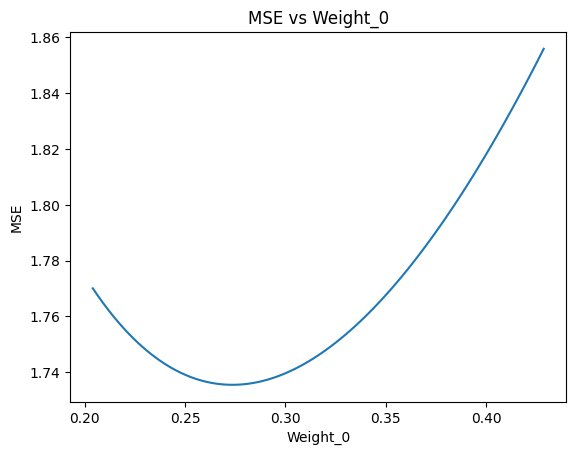

In [92]:
w_0_values = [arithmetic_sequence(k)[0] for k in k_values]
# 绘制曲线
plt.plot(w_0_values, mse_values)
plt.xlabel('Weight_0')
plt.ylabel('MSE')
plt.title('MSE vs Weight_0')
plt.show()

In [170]:
# 找到 mse_values 的最小值及其对应的 k_value
min_mse_index = np.argmin(mse_values)


In [171]:
import numpy as np

#非空的20个
def find_closest_values_without_null(x_content, property_column, df = ref_property_manual.copy()):
    df['distance'] = df['content'].apply(lambda x: edit_distance(x_content, x))
    sorted_df = df.sort_values(by='distance', ascending=1) #True是从小往大排
    
    # 获取非空值的列表
    non_null_values = [value for value in sorted_df[property_column] if pd.notnull(value)]
    #print([value for value in sorted_df["content"] if pd.notnull(value)][:20])
    # 返回最近的10个非空值
    #print(non_null_values[:5])
    #print([value for value in sorted_df['content'] if pd.notnull(value)][:5])
    #print([value for value in sorted_df['distance'] if pd.notnull(value)][:5])
    #return non_null_values[:20]
    return non_null_values[:5]

    #return non_null_values[1:6] #先用1:6 寻找泛化能力强的组合再改成：5进行应用


find_closest_values_without_null("white oil","density")




[818.5, 1000.0, 935.0, 950.0, 997.0]

In [172]:
min_k_value = k_values[min_mse_index]
min_mse = target_fuc_density(min_k_value)

min_mse, min_k_value


(0.9341158760412301, 0.17333333333333334)

In [173]:
min_mse, min_k_value = (1.390158670722062, 0.08282828282828283)
#predict()
estimated_value(arithmetic_sequence(min_k_value),"white oil","density")

934.8939480174154

In [174]:
import sys
print(sys.executable)

C:\Users\Krog\.conda\envs\glm_2\python.exe


In [175]:
import pandas as pd
merged_df = pd.read_csv('merged_df_manual.csv')
filled_df = merged_df.copy()
#filled_df.head(40)
filled_df

,Unnamed: 0,type,c_content,c_Q,c_V,c_density,c_viscosity,c_interface tension,c_channel’s width,c_channel’s depth,...,d_content,d_Q,d_V,d_density,d_viscosity,d_interface tension,d_channel’s width,d_channel’s depth,d_weber number,d_capillary number
0,11.5,squeezing,Silicone oil KF96-10cs,7.800000e-09,NaN,NaN,0.000034,0.000030,0.200,0.100,...,water,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10.5,jetting,50 wt% glycerol solution with 1 wt% SDS,3.666667e-05,NaN,NaN,0.006920,0.018125,0.108,0.750,...,gas,1.666667e-06,NaN,NaN,0.000194,NaN,NaN,NaN,NaN,NaN
2,15.5,jetting,Isobutylene-isoprene rubber (IIR) solution,2.270833e-05,NaN,696.0,0.142200,0.029530,0.400,0.365,...,Deionized water,5.205000e-07,NaN,998.0,0.000890,0.00100,0.0750,NaN,0.0457,NaN
3,14.0,squeezing,oil,NaN,0.1800,NaN,NaN,NaN,NaN,NaN,...,water,NaN,0.18,NaN,NaN,NaN,0.2000,0.100,NaN,NaN
4,15.5,squeezing,Kerosene,NaN,0.2000,NaN,NaN,NaN,NaN,6.000,...,Water,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336,10.5,dripping,mineral oil with a surfactant (Span 80) at a c...,1.666667e-07,NaN,NaN,NaN,NaN,0.100,0.050,...,DI water with 60.5 wt. % glycerin,1.666667e-09,NaN,NaN,0.009000,0.00334,0.1000,NaN,NaN,NaN
337,3.0,dripping,oil,NaN,0.4322,1940.0,0.002330,0.021100,NaN,NaN,...,crystallization solution,2.910000e-07,NaN,1013.0,0.000280,NaN,0.5080,NaN,NaN,NaN
338,19.5,squeezing,ethanol,5.000000e-08,NaN,809.0,0.001005,0.025900,0.200,0.152,...,ethanol (liquid),3.000000e-06,NaN,179.0,0.000020,NaN,0.2175,0.866,NaN,NaN
339,7.0,squeezing,Liquid,NaN,NaN,NaN,0.100000,0.020800,NaN,NaN,...,Silicone oil 47V100,2.520000e+00,NaN,NaN,1.100000,0.06290,NaN,NaN,NaN,NaN


In [176]:

def predict(text,prop): #预测某个性质
    return estimated_value(arithmetic_sequence(min_k_value),text,prop)


In [177]:
import math

#现在对密度和黏度进行补齐
#给定组成，查找性质
def find_property_value(x_content, property, ref_property_manual = ref_property_manual):
    # 首先检查列是否存在
    if "content" not in ref_property_manual.columns or property not in ref_property_manual.columns:
        raise ValueError("The specified columns are not in the DataFrame.")
    #print(type(x_content))
    # 在"content"列中查找与x_content匹配的行
    
    if isinstance(x_content, float):
        if  math.isnan(x_content): #组成是空值
            return  ref_property_manual[property].mean() #返回平均值，之后是不是可以考虑中位数
        else: #是不空的浮点数
            print(x_content)
            x_content = str(x_content)
        
    matching_row = ref_property_manual.loc[ref_property_manual['content'] == x_content.lower()] #注意这里要小写
    
    # 如果存在匹配的行，且该行内容不为空值，则返回该行的"property"列的值
    if not (matching_row.empty or math.isnan(matching_row.iloc[0][property])):
        return matching_row.iloc[0][property]
    else:
        return predict(x_content.lower(),property)  # 如果没有找到匹配的行，则预测一个
    
find_property_value("ethanol","density")

799.0

In [178]:
filled_df

,Unnamed: 0,type,c_content,c_Q,c_V,c_density,c_viscosity,c_interface tension,c_channel’s width,c_channel’s depth,...,d_content,d_Q,d_V,d_density,d_viscosity,d_interface tension,d_channel’s width,d_channel’s depth,d_weber number,d_capillary number
0,11.5,squeezing,Silicone oil KF96-10cs,7.800000e-09,NaN,NaN,0.000034,0.000030,0.200,0.100,...,water,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10.5,jetting,50 wt% glycerol solution with 1 wt% SDS,3.666667e-05,NaN,NaN,0.006920,0.018125,0.108,0.750,...,gas,1.666667e-06,NaN,NaN,0.000194,NaN,NaN,NaN,NaN,NaN
2,15.5,jetting,Isobutylene-isoprene rubber (IIR) solution,2.270833e-05,NaN,696.0,0.142200,0.029530,0.400,0.365,...,Deionized water,5.205000e-07,NaN,998.0,0.000890,0.00100,0.0750,NaN,0.0457,NaN
3,14.0,squeezing,oil,NaN,0.1800,NaN,NaN,NaN,NaN,NaN,...,water,NaN,0.18,NaN,NaN,NaN,0.2000,0.100,NaN,NaN
4,15.5,squeezing,Kerosene,NaN,0.2000,NaN,NaN,NaN,NaN,6.000,...,Water,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336,10.5,dripping,mineral oil with a surfactant (Span 80) at a c...,1.666667e-07,NaN,NaN,NaN,NaN,0.100,0.050,...,DI water with 60.5 wt. % glycerin,1.666667e-09,NaN,NaN,0.009000,0.00334,0.1000,NaN,NaN,NaN
337,3.0,dripping,oil,NaN,0.4322,1940.0,0.002330,0.021100,NaN,NaN,...,crystallization solution,2.910000e-07,NaN,1013.0,0.000280,NaN,0.5080,NaN,NaN,NaN
338,19.5,squeezing,ethanol,5.000000e-08,NaN,809.0,0.001005,0.025900,0.200,0.152,...,ethanol (liquid),3.000000e-06,NaN,179.0,0.000020,NaN,0.2175,0.866,NaN,NaN
339,7.0,squeezing,Liquid,NaN,NaN,NaN,0.100000,0.020800,NaN,NaN,...,Silicone oil 47V100,2.520000e+00,NaN,NaN,1.100000,0.06290,NaN,NaN,NaN,NaN


In [179]:
# 假设 filled_df 是你的数据框

def fill(phase, prop): #phase是“c_”,prop是“density”
    
    global filled_df
    
    content_column = phase + "content"
    
    prop_column = phase + prop
    
    for index, row in filled_df.iterrows():
        if pd.isnull(row[prop_column]):  # 检查是否为空值
            # 使用 find_property_value 函数获取同一行 'c_content' 列的值
            filled_df.at[index, prop_column] = find_property_value(row[content_column],prop)

# 这里假设 find_property_value 函数是你定义好的函数，根据 'c_content' 列的值来获取对应的属性值
fill("c_", "density")
fill("d_", "density")
filled_df

,Unnamed: 0,type,c_content,c_Q,c_V,c_density,c_viscosity,c_interface tension,c_channel’s width,c_channel’s depth,...,d_content,d_Q,d_V,d_density,d_viscosity,d_interface tension,d_channel’s width,d_channel’s depth,d_weber number,d_capillary number
0,11.5,squeezing,Silicone oil KF96-10cs,7.800000e-09,NaN,1005.202228,0.000034,0.000030,0.200,0.100,...,water,NaN,NaN,1000.00000,NaN,NaN,NaN,NaN,NaN,NaN
1,10.5,jetting,50 wt% glycerol solution with 1 wt% SDS,3.666667e-05,NaN,1058.948827,0.006920,0.018125,0.108,0.750,...,gas,1.666667e-06,NaN,800.00000,0.000194,NaN,NaN,NaN,NaN,NaN
2,15.5,jetting,Isobutylene-isoprene rubber (IIR) solution,2.270833e-05,NaN,696.000000,0.142200,0.029530,0.400,0.365,...,Deionized water,5.205000e-07,NaN,998.00000,0.000890,0.00100,0.0750,NaN,0.0457,NaN
3,14.0,squeezing,oil,NaN,0.1800,1000.000000,NaN,NaN,NaN,NaN,...,water,NaN,0.18,1000.00000,NaN,NaN,0.2000,0.100,NaN,NaN
4,15.5,squeezing,Kerosene,NaN,0.2000,801.717678,NaN,NaN,NaN,6.000,...,Water,NaN,NaN,1000.00000,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336,10.5,dripping,mineral oil with a surfactant (Span 80) at a c...,1.666667e-07,NaN,932.147075,NaN,NaN,0.100,0.050,...,DI water with 60.5 wt. % glycerin,1.666667e-09,NaN,967.77144,0.009000,0.00334,0.1000,NaN,NaN,NaN
337,3.0,dripping,oil,NaN,0.4322,1940.000000,0.002330,0.021100,NaN,NaN,...,crystallization solution,2.910000e-07,NaN,1013.00000,0.000280,NaN,0.5080,NaN,NaN,NaN
338,19.5,squeezing,ethanol,5.000000e-08,NaN,809.000000,0.001005,0.025900,0.200,0.152,...,ethanol (liquid),3.000000e-06,NaN,179.00000,0.000020,NaN,0.2175,0.866,NaN,NaN
339,7.0,squeezing,Liquid,NaN,NaN,15.150000,0.100000,0.020800,NaN,NaN,...,Silicone oil 47V100,2.520000e+00,NaN,967.50000,1.100000,0.06290,NaN,NaN,NaN,NaN


In [180]:
fill("c_", "viscosity")
fill("d_", "viscosity")
filled_df

,Unnamed: 0,type,c_content,c_Q,c_V,c_density,c_viscosity,c_interface tension,c_channel’s width,c_channel’s depth,...,d_content,d_Q,d_V,d_density,d_viscosity,d_interface tension,d_channel’s width,d_channel’s depth,d_weber number,d_capillary number
0,11.5,squeezing,Silicone oil KF96-10cs,7.800000e-09,NaN,1005.202228,0.000034,0.000030,0.200,0.100,...,water,NaN,NaN,1000.00000,0.001000,NaN,NaN,NaN,NaN,NaN
1,10.5,jetting,50 wt% glycerol solution with 1 wt% SDS,3.666667e-05,NaN,1058.948827,0.006920,0.018125,0.108,0.750,...,gas,1.666667e-06,NaN,800.00000,0.000194,NaN,NaN,NaN,NaN,NaN
2,15.5,jetting,Isobutylene-isoprene rubber (IIR) solution,2.270833e-05,NaN,696.000000,0.142200,0.029530,0.400,0.365,...,Deionized water,5.205000e-07,NaN,998.00000,0.000890,0.00100,0.0750,NaN,0.0457,NaN
3,14.0,squeezing,oil,NaN,0.1800,1000.000000,0.001000,NaN,NaN,NaN,...,water,NaN,0.18,1000.00000,0.001000,NaN,0.2000,0.100,NaN,NaN
4,15.5,squeezing,Kerosene,NaN,0.2000,801.717678,0.043549,NaN,NaN,6.000,...,Water,NaN,NaN,1000.00000,0.001000,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336,10.5,dripping,mineral oil with a surfactant (Span 80) at a c...,1.666667e-07,NaN,932.147075,0.019495,NaN,0.100,0.050,...,DI water with 60.5 wt. % glycerin,1.666667e-09,NaN,967.77144,0.009000,0.00334,0.1000,NaN,NaN,NaN
337,3.0,dripping,oil,NaN,0.4322,1940.000000,0.002330,0.021100,NaN,NaN,...,crystallization solution,2.910000e-07,NaN,1013.00000,0.000280,NaN,0.5080,NaN,NaN,NaN
338,19.5,squeezing,ethanol,5.000000e-08,NaN,809.000000,0.001005,0.025900,0.200,0.152,...,ethanol (liquid),3.000000e-06,NaN,179.00000,0.000020,NaN,0.2175,0.866,NaN,NaN
339,7.0,squeezing,Liquid,NaN,NaN,15.150000,0.100000,0.020800,NaN,NaN,...,Silicone oil 47V100,2.520000e+00,NaN,967.50000,1.100000,0.06290,NaN,NaN,NaN,NaN


In [181]:
import pandas as pd
import numpy as np

# 假设filled_df是你的DataFrame

# 计算各列的平均值
#print(filled_df['c_interface tension'])
c_mean = filled_df['c_interface tension'].mean(skipna=True)
d_mean = filled_df['d_interface tension'].mean(skipna=True)


def fill_2indexs(df,index1,index2,if_mean=True): #两个列互相补充,最后一个参数决定是否填充平均值，对于Q\V这两个参数不需要，误差太大
    for index, row in df.iterrows():

        c_value = row[index1]
        d_value = row[index2]
        try:
            if (pd.isna(c_value) or c_value == 0) and not pd.isna(d_value):
                df.at[index,index1] = d_value
            elif (pd.isna(d_value) or d_value == 0) and not pd.isna(c_value):
                df.at[index, index2] = c_value
            elif (pd.isna(c_value) or c_value == 0) and (pd.isna(d_value) or d_value == 0) and if_mean == True :
                df.at[index,index1] = c_mean
                df.at[index, index2] = d_mean
        except Exception as e:
            print(c_value,d_value)
            
fill_2indexs(filled_df,'c_interface tension','d_interface tension')
#fill_2indexs(filled_df,'c_channel’s width','d_channel’s width') 通道先用QV关系算一下
fill_2indexs(filled_df,'c_channel’s depth','d_channel’s depth')

#print(filled_df)
filled_df

,Unnamed: 0,type,c_content,c_Q,c_V,c_density,c_viscosity,c_interface tension,c_channel’s width,c_channel’s depth,...,d_content,d_Q,d_V,d_density,d_viscosity,d_interface tension,d_channel’s width,d_channel’s depth,d_weber number,d_capillary number
0,11.5,squeezing,Silicone oil KF96-10cs,7.800000e-09,NaN,1005.202228,0.000034,0.000030,0.200,0.100000,...,water,NaN,NaN,1000.00000,0.001000,0.000030,NaN,0.100000,NaN,NaN
1,10.5,jetting,50 wt% glycerol solution with 1 wt% SDS,3.666667e-05,NaN,1058.948827,0.006920,0.018125,0.108,0.750000,...,gas,1.666667e-06,NaN,800.00000,0.000194,0.018125,NaN,0.750000,NaN,NaN
2,15.5,jetting,Isobutylene-isoprene rubber (IIR) solution,2.270833e-05,NaN,696.000000,0.142200,0.029530,0.400,0.365000,...,Deionized water,5.205000e-07,NaN,998.00000,0.000890,0.001000,0.0750,0.365000,0.0457,NaN
3,14.0,squeezing,oil,NaN,0.1800,1000.000000,0.001000,821.630732,NaN,0.100000,...,water,NaN,0.18,1000.00000,0.001000,0.287594,0.2000,0.100000,NaN,NaN
4,15.5,squeezing,Kerosene,NaN,0.2000,801.717678,0.043549,821.630732,NaN,6.000000,...,Water,NaN,NaN,1000.00000,0.001000,0.287594,NaN,6.000000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336,10.5,dripping,mineral oil with a surfactant (Span 80) at a c...,1.666667e-07,NaN,932.147075,0.019495,0.003340,0.100,0.050000,...,DI water with 60.5 wt. % glycerin,1.666667e-09,NaN,967.77144,0.009000,0.003340,0.1000,0.050000,NaN,NaN
337,3.0,dripping,oil,NaN,0.4322,1940.000000,0.002330,0.021100,NaN,821.630732,...,crystallization solution,2.910000e-07,NaN,1013.00000,0.000280,0.021100,0.5080,0.287594,NaN,NaN
338,19.5,squeezing,ethanol,5.000000e-08,NaN,809.000000,0.001005,0.025900,0.200,0.152000,...,ethanol (liquid),3.000000e-06,NaN,179.00000,0.000020,0.025900,0.2175,0.866000,NaN,NaN
339,7.0,squeezing,Liquid,NaN,NaN,15.150000,0.100000,0.020800,NaN,821.630732,...,Silicone oil 47V100,2.520000e+00,NaN,967.50000,1.100000,0.062900,NaN,0.287594,NaN,NaN


In [182]:
#用于QV计算W
import pandas as pd
import math

def calculate_qvw(df, Q, V, W): #互相计算填充
    """
    遍历DataFrame的每一行，如果df[W]为空且df[Q]和df[V]非空，
    则计算 sqrt(q/v) * 10^3 并赋值给df[W]。

    参数:
    df -- pandas DataFrame对象
    Q -- Q列的名称
    V -- V列的名称
    W -- W列的名称
    """
    # 遍历DataFrame的每一行
    for index, row in df.iterrows():
        # 检查W列的值是否为空或NaN
        
        if pd.isnull(row[W]) or math.isnan(row[W]):
            q = row[Q]
            v = row[V]
            # 检查Q和V列的值是否非空且非NaN
            if not (pd.isnull(q) or math.isnan(q)) and not (pd.isnull(v) or math.isnan(v)):
                # 计算新的W列值
                df.at[index, W] = (math.sqrt(q / v)) * 10**3
                print(df.at[index, W])
                
        elif pd.isnull(row[Q]) or math.isnan(row[Q]):
            v = row[V]
            w = row[W]
            if pd.notnull(v) and pd.notnull(w) and not math.isnan(v) and not math.isnan(w):
                df.at[index, Q] = (w / 1000) ** 2 * v
                print(df.at[index, Q])
                
        elif pd.isnull(row[V]) or math.isnan(row[V]):
            w = row[W]
            q = row[Q]
            if pd.notnull(q) and pd.notnull(w) and not math.isnan(q) and not math.isnan(w):
                df.at[index, V] = q/((w / 1000) ** 2) 
                print(df.at[index, V])
                
    return df

# 示例使用
# 假设有一个DataFrame 'df' 和对应的列名 'Q', 'V', 'W'
# df = pd.DataFrame({
#     'Q': [10, None, 15, 20],
#     'V': [5, 10, None, 25],
#     'W': [None, None, None, None]
# })
# 调用函数
# df = calculate_w(df, 'Q', 'V', 'W')
# print(df)



''''
def calculate_q(df, Q, V, W):
    """
    Fill missing values in column Q based on the values in columns V and W.
    
    Parameters:
    - df: pandas DataFrame
    - Q: str, name of the column to fill
    - V: str, name of the column for values
    - W: str, name of the column for weights
    
    Returns:
    - df: pandas DataFrame with filled values
    """
    for index, row in df.iterrows():
        if pd.isnull(row[Q]) or math.isnan(row[Q]):
            v = row[V]
            w = row[W]
            if pd.notnull(v) and pd.notnull(w) and not math.isnan(v) and not math.isnan(w):
                df.at[index, Q] = (w / 1000) ** 2 * v
    return df

# Example usage
example_df = pd.DataFrame({
    'Q': [None, 5, None],
    'V': [10, 10, 10],
    'W': [1000, 2000, 3000]
})

filled_df = fill_missing_values(example_df, 'Q', 'V', 'W')
filled_df
'''
filled_df = calculate_qvw(filled_df, "c_Q", "c_V", "c_channel’s width")
filled_df = calculate_qvw(filled_df, "d_Q", "d_V", "d_channel’s width")
fill_2indexs(filled_df,'c_channel’s width','d_channel’s width')  #再用前面的方法填充
fill_2indexs(filled_df,'c_Q','d_Q',False)
fill_2indexs(filled_df,'c_V','d_V',False)
#有填充的了再算一遍
filled_df = calculate_qvw(filled_df, "c_Q", "c_V", "c_channel’s width")
filled_df = calculate_qvw(filled_df, "d_Q", "d_V", "d_channel’s width")

0.195
3143.5756744398727
141.92708333333331
0.004261725914927068
0.01601947968729975
41.6875
0.07555555555555554
0.07139483330201299
4.20080151228735
0.00868055625
1.7361111111111114
0.10233926881443117
2.9249999999999996e-11
0.0833125
0.0015625
1.3875
0.006944444444444444
11.574074074074078
20.833333333333332
15.0462962962963
0.01851851851851852
69.2820323027551
0.014
13.888888888888893
0.004
0.0004611764705882353
13.888888888888891
0.0034750000000000002
0.0625
166.667
1.7000000000000001e-07
0.006751543209876541
0.004251700680272109
2.02e-09
1.5625
0.64
311.1111111111111
12.510189528992308
116.66666666660001
0.0011041666666666665
0.0004166666666666667
69.44444444444443
0.09141289437585733
0.029688888888888893
2.77778
0.006882
0.008369856342829314
0.014171366046629075
2996.618013527946
5.402699999999998e-10
0.052062500000000005
1.9229756805485738
0.0033333000000000004
1.9250000000000003
1.5625
0.015625
0.8
8e-10
0.17777777777777778
0.005833333333333334
1.26e-06
208.33325000000002
0.019

In [183]:
filled_df

,Unnamed: 0,type,c_content,c_Q,c_V,c_density,c_viscosity,c_interface tension,c_channel’s width,c_channel’s depth,...,d_content,d_Q,d_V,d_density,d_viscosity,d_interface tension,d_channel’s width,d_channel’s depth,d_weber number,d_capillary number
0,11.5,squeezing,Silicone oil KF96-10cs,7.800000e-09,0.195000,1005.202228,0.000034,0.000030,0.200000,0.100000,...,water,7.800000e-09,1.950000e-01,1000.00000,0.001000,0.000030,0.200000,0.100000,NaN,NaN
1,10.5,jetting,50 wt% glycerol solution with 1 wt% SDS,3.666667e-05,3143.575674,1058.948827,0.006920,0.018125,0.108000,0.750000,...,gas,1.666667e-06,3.143576e+03,800.00000,0.000194,0.018125,0.108000,0.750000,NaN,NaN
2,15.5,jetting,Isobutylene-isoprene rubber (IIR) solution,2.270833e-05,141.927083,696.000000,0.142200,0.029530,0.400000,0.365000,...,Deionized water,5.205000e-07,9.253333e+01,998.00000,0.000890,0.001000,0.075000,0.365000,0.0457,NaN
3,14.0,squeezing,oil,7.200000e-09,0.180000,1000.000000,0.001000,821.630732,0.200000,0.100000,...,water,7.200000e-09,1.800000e-01,1000.00000,0.001000,0.287594,0.200000,0.100000,NaN,NaN
4,15.5,squeezing,Kerosene,1.350154e-01,0.200000,801.717678,0.043549,821.630732,821.630732,6.000000,...,Water,1.654201e-08,2.000000e-01,1000.00000,0.001000,0.287594,0.287594,6.000000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336,10.5,dripping,mineral oil with a surfactant (Span 80) at a c...,1.666667e-07,16.666667,932.147075,0.019495,0.003340,0.100000,0.050000,...,DI water with 60.5 wt. % glycerin,1.666667e-09,1.666667e-01,967.77144,0.009000,0.003340,0.100000,0.050000,NaN,NaN
337,3.0,dripping,oil,2.910000e-07,0.432200,1940.000000,0.002330,0.021100,0.508000,821.630732,...,crystallization solution,2.910000e-07,1.127627e+00,1013.00000,0.000280,0.021100,0.508000,0.287594,NaN,NaN
338,19.5,squeezing,ethanol,5.000000e-08,1.250000,809.000000,0.001005,0.025900,0.200000,0.152000,...,ethanol (liquid),3.000000e-06,6.341657e+01,179.00000,0.000020,0.025900,0.217500,0.866000,NaN,NaN
339,7.0,squeezing,Liquid,2.520000e+00,3.732907,15.150000,0.100000,0.020800,821.630732,821.630732,...,Silicone oil 47V100,2.520000e+00,3.046787e+07,967.50000,1.100000,0.062900,0.287594,0.287594,NaN,NaN


$$
We = \frac{\rho v^2 L}{\sigma} \\
Ca = \frac{\mu v}{\sigma}
$$

In [184]:
#计算两个准数
#先用宽度代替L，用速度代替特征剪切速率v
def calculate_we_ca(df,phase): #计算ca和we，phase是“c_”或者"d_"
    
    #以下大写的都是列名字
    RHO = phase + "density"
    V = phase + "V"
    W = phase + "channel’s width"
    SIGMA = phase + "interface tension"
    MU = phase + "viscosity"
    WE = phase + "weber number"
    CA = phase + "capillary number"

  
    # 遍历DataFrame的每一行
    for index, row in df.iterrows():
        # 检查列的值是否为空或NaN
        
        # 小写的都是变量
        rho = row[RHO]
        v = row[V]
        w = row[W]  # channel's width
        sigma = row[SIGMA]  # interface tension
        mu = row[MU]  # viscosity
        we = row[WE]  # weber number
        ca = row[CA]  # capillary number
        
        if pd.isnull(we) or math.isnan(we):

            # 检查V列的值是否非空且非NaN
            if not (pd.isnull(v) or math.isnan(v)):
                # 计算新的we列值
                df.at[index, WE] = rho * (v ** 2) * w / (1000 * sigma) #1000是因为w毫米
                #print(df.at[index, WE])
                
        elif (pd.isnull(ca) or math.isnan(ca)) and (pd.isnull(v) or math.isnan(v)): #如果毛细管和速度是空着的 
            
            # 计算新的v列值
            df.at[index, V] = (math.sqrt((we * sigma) / (rho * w / 1000))) #1000是因为w毫米
            
                
        if pd.isnull(ca) or math.isnan(ca):

            # 检查V列的值是否非空且非NaN
            if not (pd.isnull(v) or math.isnan(v)):
                # 计算新的ca列值
                df.at[index, CA] = mu * v / (sigma) 
                #print(df.at[index, CA])
                
        elif (pd.isnull(we) or math.isnan(we)) and (pd.isnull(v) or math.isnan(v)): #如果韦伯数和速度是空着的
            #print(mu)
            df.at[index, V] = (ca * sigma) / mu
                
                
    return df

In [185]:
filled_df = calculate_we_ca(filled_df,"c_")
filled_df = calculate_we_ca(filled_df,"d_")


In [186]:
#有填充的了再算一遍
filled_df = calculate_qvw(filled_df, "c_Q", "c_V", "c_channel’s width")
filled_df = calculate_qvw(filled_df, "d_Q", "d_V", "d_channel’s width")
filled_df = calculate_we_ca(filled_df,"c_")
filled_df = calculate_we_ca(filled_df,"d_")
fill_2indexs(filled_df,'c_Q','d_Q',False)
fill_2indexs(filled_df,'c_V','d_V',False)
filled_df = calculate_qvw(filled_df, "c_Q", "c_V", "c_channel’s width")
filled_df = calculate_qvw(filled_df, "d_Q", "d_V", "d_channel’s width")
filled_df = calculate_we_ca(filled_df,"c_")
filled_df = calculate_we_ca(filled_df,"d_")

5.826666666666666e-11
207.6931624291169
0.01703635433932464
4.108153657630908e-06
0.01643261463052363
2.826409716450065e-09
4.6875e-11
3.385005055043394e-08
3.0810045235578235e-10
8.216307315261818e-07
1.4256410256410256e-10
6.797752808988765e-13
1.5299999999999995e-11
4.658453551122352e-06
7.924528301886792e-09
9.498518778464978e-09
1.2390727411058768e-07
9.503090433271342e-11
6.320224719101124e-11
9.38274058608871e-10
5.521609538002981e-11
1.8405989195698925e-05
5.580740170576827e-08


In [187]:
filled_df

,Unnamed: 0,type,c_content,c_Q,c_V,c_density,c_viscosity,c_interface tension,c_channel’s width,c_channel’s depth,...,d_content,d_Q,d_V,d_density,d_viscosity,d_interface tension,d_channel’s width,d_channel’s depth,d_weber number,d_capillary number
0,11.5,squeezing,Silicone oil KF96-10cs,7.800000e-09,0.195000,1005.202228,0.000034,0.000030,0.200000,0.100000,...,water,7.800000e-09,1.950000e-01,1000.00000,0.001000,0.000030,0.200000,0.100000,2.535000e+02,6.500000e+00
1,10.5,jetting,50 wt% glycerol solution with 1 wt% SDS,3.666667e-05,3143.575674,1058.948827,0.006920,0.018125,0.108000,0.750000,...,gas,1.666667e-06,3.143576e+03,800.00000,0.000194,0.018125,0.108000,0.750000,4.710680e+07,3.358640e+01
2,15.5,jetting,Isobutylene-isoprene rubber (IIR) solution,2.270833e-05,141.927083,696.000000,0.142200,0.029530,0.400000,0.365000,...,Deionized water,5.205000e-07,9.253333e+01,998.00000,0.000890,0.001000,0.075000,0.365000,4.570000e-02,8.235467e+01
3,14.0,squeezing,oil,7.200000e-09,0.180000,1000.000000,0.001000,821.630732,0.200000,0.100000,...,water,7.200000e-09,1.800000e-01,1000.00000,0.001000,0.287594,0.200000,0.100000,2.253180e-02,6.258832e-04
4,15.5,squeezing,Kerosene,1.350154e-01,0.200000,801.717678,0.043549,821.630732,821.630732,6.000000,...,Water,1.654201e-08,2.000000e-01,1000.00000,0.001000,0.287594,0.287594,6.000000,4.000000e-02,6.954258e-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336,10.5,dripping,mineral oil with a surfactant (Span 80) at a c...,1.666667e-07,16.666667,932.147075,0.019495,0.003340,0.100000,0.050000,...,DI water with 60.5 wt. % glycerin,1.666667e-09,1.666667e-01,967.77144,0.009000,0.003340,0.100000,0.050000,8.048665e-01,4.491018e-01
337,3.0,dripping,oil,2.910000e-07,0.432200,1940.000000,0.002330,0.021100,0.508000,821.630732,...,crystallization solution,2.910000e-07,1.127627e+00,1013.00000,0.000280,0.021100,0.508000,0.287594,3.101143e+01,1.496377e-02
338,19.5,squeezing,ethanol,5.000000e-08,1.250000,809.000000,0.001005,0.025900,0.200000,0.152000,...,ethanol (liquid),3.000000e-06,6.341657e+01,179.00000,0.000020,0.025900,0.217500,0.866000,6.045302e+03,4.799092e-02
339,7.0,squeezing,Liquid,2.520000e+00,3.732907,15.150000,0.100000,0.020800,821.630732,821.630732,...,Silicone oil 47V100,2.520000e+00,3.046787e+07,967.50000,1.100000,0.062900,0.287594,0.287594,4.106425e+15,5.328245e+08


In [188]:
#删除多余列和行
filled_df = filled_df.drop('Unnamed: 0', axis=1)
filled_df = filled_df.drop('c_content', axis=1)
filled_df = filled_df.drop('d_content', axis=1)
filled_df

,type,c_Q,c_V,c_density,c_viscosity,c_interface tension,c_channel’s width,c_channel’s depth,c_weber number,c_capillary number,d_Q,d_V,d_density,d_viscosity,d_interface tension,d_channel’s width,d_channel’s depth,d_weber number,d_capillary number
0,squeezing,7.800000e-09,0.195000,1005.202228,0.000034,0.000030,0.200000,0.100000,2.548188e+02,9.600000e-02,7.800000e-09,1.950000e-01,1000.00000,0.001000,0.000030,0.200000,0.100000,2.535000e+02,6.500000e+00
1,jetting,3.666667e-05,3143.575674,1058.948827,0.006920,0.018125,0.108000,0.750000,6.235461e+07,1.750000e-01,1.666667e-06,3.143576e+03,800.00000,0.000194,0.018125,0.108000,0.750000,4.710680e+07,3.358640e+01
2,jetting,2.270833e-05,141.927083,696.000000,0.142200,0.029530,0.400000,0.365000,1.899050e+05,6.650000e-01,5.205000e-07,9.253333e+01,998.00000,0.000890,0.001000,0.075000,0.365000,4.570000e-02,8.235467e+01
3,squeezing,7.200000e-09,0.180000,1000.000000,0.001000,821.630732,0.200000,0.100000,7.886755e-06,2.190765e-07,7.200000e-09,1.800000e-01,1000.00000,0.001000,0.287594,0.200000,0.100000,2.253180e-02,6.258832e-04
4,squeezing,1.350154e-01,0.200000,801.717678,0.043549,821.630732,821.630732,6.000000,3.206871e-02,1.000000e-02,1.654201e-08,2.000000e-01,1000.00000,0.001000,0.287594,0.287594,6.000000,4.000000e-02,6.954258e-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336,dripping,1.666667e-07,16.666667,932.147075,0.019495,0.003340,0.100000,0.050000,7.752388e+03,9.727928e+01,1.666667e-09,1.666667e-01,967.77144,0.009000,0.003340,0.100000,0.050000,8.048665e-01,4.491018e-01
337,dripping,2.910000e-07,0.432200,1940.000000,0.002330,0.021100,0.508000,821.630732,8.724740e+00,4.772635e-02,2.910000e-07,1.127627e+00,1013.00000,0.000280,0.021100,0.508000,0.287594,3.101143e+01,1.496377e-02
338,squeezing,5.000000e-08,1.250000,809.000000,0.001005,0.025900,0.200000,0.152000,9.761100e+00,5.000000e-03,3.000000e-06,6.341657e+01,179.00000,0.000020,0.025900,0.217500,0.866000,6.045302e+03,4.799092e-02
339,squeezing,2.520000e+00,3.732907,15.150000,0.100000,0.020800,821.630732,821.630732,8.339123e+03,5.000000e-03,2.520000e+00,3.046787e+07,967.50000,1.100000,0.062900,0.287594,0.287594,4.106425e+15,5.328245e+08


In [189]:
# 删除含有空值或NaN的行
filled_df = filled_df.dropna()

filled_df

,type,c_Q,c_V,c_density,c_viscosity,c_interface tension,c_channel’s width,c_channel’s depth,c_weber number,c_capillary number,d_Q,d_V,d_density,d_viscosity,d_interface tension,d_channel’s width,d_channel’s depth,d_weber number,d_capillary number
0,squeezing,7.800000e-09,0.195000,1005.202228,0.000034,0.000030,0.200000,0.100000,2.548188e+02,9.600000e-02,7.800000e-09,1.950000e-01,1000.00000,0.001000,0.000030,0.200000,0.100000,2.535000e+02,6.500000e+00
1,jetting,3.666667e-05,3143.575674,1058.948827,0.006920,0.018125,0.108000,0.750000,6.235461e+07,1.750000e-01,1.666667e-06,3.143576e+03,800.00000,0.000194,0.018125,0.108000,0.750000,4.710680e+07,3.358640e+01
2,jetting,2.270833e-05,141.927083,696.000000,0.142200,0.029530,0.400000,0.365000,1.899050e+05,6.650000e-01,5.205000e-07,9.253333e+01,998.00000,0.000890,0.001000,0.075000,0.365000,4.570000e-02,8.235467e+01
3,squeezing,7.200000e-09,0.180000,1000.000000,0.001000,821.630732,0.200000,0.100000,7.886755e-06,2.190765e-07,7.200000e-09,1.800000e-01,1000.00000,0.001000,0.287594,0.200000,0.100000,2.253180e-02,6.258832e-04
4,squeezing,1.350154e-01,0.200000,801.717678,0.043549,821.630732,821.630732,6.000000,3.206871e-02,1.000000e-02,1.654201e-08,2.000000e-01,1000.00000,0.001000,0.287594,0.287594,6.000000,4.000000e-02,6.954258e-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335,squeezing,1.458333e-05,22.786458,1205.000000,0.018080,0.072880,0.800000,0.900000,1.000000e+01,9.255000e-05,1.500000e-06,2.278646e+01,998.20000,0.001002,0.072880,0.800000,0.900000,5.689222e+03,3.132825e-01
336,dripping,1.666667e-07,16.666667,932.147075,0.019495,0.003340,0.100000,0.050000,7.752388e+03,9.727928e+01,1.666667e-09,1.666667e-01,967.77144,0.009000,0.003340,0.100000,0.050000,8.048665e-01,4.491018e-01
337,dripping,2.910000e-07,0.432200,1940.000000,0.002330,0.021100,0.508000,821.630732,8.724740e+00,4.772635e-02,2.910000e-07,1.127627e+00,1013.00000,0.000280,0.021100,0.508000,0.287594,3.101143e+01,1.496377e-02
338,squeezing,5.000000e-08,1.250000,809.000000,0.001005,0.025900,0.200000,0.152000,9.761100e+00,5.000000e-03,3.000000e-06,6.341657e+01,179.00000,0.000020,0.025900,0.217500,0.866000,6.045302e+03,4.799092e-02


In [190]:
filled_df.to_csv("post//filled_df.csv",encoding = "utf-8")